<a href="https://colab.research.google.com/github/elifguv/lulc-monitoring/blob/main/Senior_project_MS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!wget "https://zenodo.org/records/7711810/files/EuroSAT_MS.zip?download=1" -O EuroSAT_MS.zip

--2026-06-02 16:43:42--  https://zenodo.org/records/7711810/files/EuroSAT_MS.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.185.43.153, 137.138.52.235, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2065402329 (1.9G) [application/octet-stream]
Saving to: ‘EuroSAT_MS.zip’

EuroSAT_MS.zip      100%[===================>]   1.92G  12.0MB/s    in 2m 51s  

2026-06-02 16:46:33 (11.5 MB/s) - ‘EuroSAT_MS.zip’ saved [2065402329/2065402329]



In [ ]:
!unzip -q EuroSAT_MS.zip -d /content/EuroSAT_MS

replace /content/EuroSAT_MS/EuroSAT_MS/Forest/Forest_2230.tif? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
A
A


In [ ]:
!pip install rasterio

In [ ]:
import os
import rasterio
import numpy as np

# Inspect the first Pasture tile
sample_path = '/content/EuroSAT_MS/EuroSAT_MS/Pasture/Pasture_598.tif'

with rasterio.open(sample_path) as src:
    # Read the raw satellite data
    raw_img = src.read()

    # Rotate the matrix axes to (Height, Width, Bands)
    keras_img = np.moveaxis(raw_img, 0, -1)

print("=== SATELLITE TILE DIAGNOSTICS ===")
print(f"1. AI Tensor Shape: {keras_img.shape}")
print(f"2. Minimum Light Value: {keras_img.min()}")
print(f"3. Maximum Light Value: {keras_img.max()}")

=== SATELLITE TILE DIAGNOSTICS ===
1. AI Tensor Shape: (64, 64, 13)
2. Minimum Light Value: 13
3. Maximum Light Value: 4317


In [ ]:
import glob

# Search for every .tif file, no matter how deeply nested it is
tif_files = glob.glob('/content/EuroSAT_MS/**/*.tif', recursive=True)

if len(tif_files) > 0:
    print(f"Found {len(tif_files)} total .tif files!")
    print("\nThe path to the first image:")
    print(tif_files[0])
else:
    print("No .tif files found. The unzip command might not have finished.")

Found 27000 total .tif files!

Here is the REAL path to the first image:
/content/EuroSAT_MS/EuroSAT_MS/Pasture/Pasture_598.tif


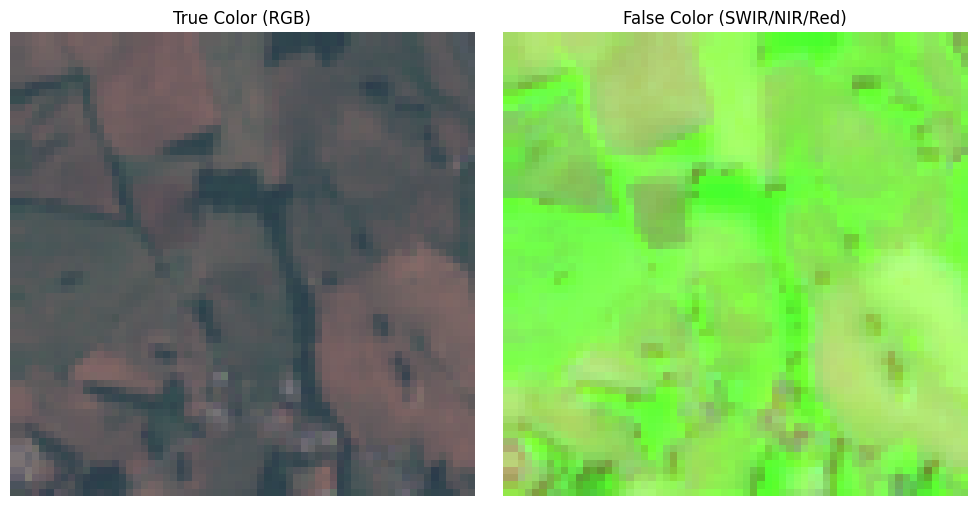

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

sample_path = '/content/EuroSAT_MS/EuroSAT_MS/Pasture/Pasture_598.tif'

def normalize_for_display(band_data, max_val=3000.0):
    """Sentinel-2 data is dark. Cap the light at 3000 for human viewing."""
    band_data = np.clip(band_data, 0, max_val)
    return band_data / max_val

with rasterio.open(sample_path) as src:
    img = src.read()

# In EuroSAT, bands are 0-indexed.
# True Color
red = img[3, :, :]
green = img[2, :, :]
blue = img[1, :, :]
rgb_human = np.stack([red, green, blue], axis=-1)
rgb_human = normalize_for_display(rgb_human)

# False Color Urban
swir = img[11, :, :] # man-made materials
nir = img[7, :, :]   # vegetation
red_band = img[3, :, :]

false_color = np.stack([swir, nir, red_band], axis=-1)
false_color = normalize_for_display(false_color)

# --- Plot the comparison ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(rgb_human)
ax1.set_title("True Color (RGB)")
ax1.axis('off')

ax2.imshow(false_color)
ax2.set_title("False Color (SWIR/NIR/Red)")
ax2.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import os
import glob
import rasterio
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence, to_categorical

# Configuration
DATA_DIR = '/content/EuroSAT_MS/EuroSAT_MS'
BATCH_SIZE = 32
IMG_SIZE = 64
CHANNELS = 13
MAX_PIXEL_VALUE = 4000.0 # Normalizes the light values down to 0-1

# Automatically find all folders (classes)
classes = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
print(f"Found {len(classes)} classes: {classes}")

# Gather file paths
filepaths = []
labels = []

for cls_name in classes:
    cls_dir = os.path.join(DATA_DIR, cls_name)
    files = glob.glob(os.path.join(cls_dir, '*.tif'))
    filepaths.extend(files)
    labels.extend([class_to_idx[cls_name]] * len(files))

print(f"Total .tif images found: {len(filepaths)}")

# Split into Training (80%) and Validation (20%)
X_train_paths, X_val_paths, y_train, y_val = train_test_split(
    filepaths, labels, test_size=0.2, random_state=42, stratify=labels
)

# Data Generator
class EuroSATGenerator(Sequence):
    def __init__(self, filepaths, labels, batch_size, num_classes):
        self.filepaths = np.array(filepaths)
        self.labels = np.array(labels)
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.indices = np.arange(len(self.filepaths))
        np.random.shuffle(self.indices) # Shuffle data for better learning

    def __len__(self):
        # Calculate how many batches are in one epoch
        return int(np.ceil(len(self.filepaths) / float(self.batch_size)))

    def __getitem__(self, idx):
        # Grab the file paths for the specific batch
        batch_indices = self.indices[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_paths = self.filepaths[batch_indices]
        batch_labels = self.labels[batch_indices]

        # Prepare empty arrays to hold the loaded data
        X = np.empty((len(batch_paths), IMG_SIZE, IMG_SIZE, CHANNELS), dtype=np.float32)

        # Open the .tif files and process them
        for i, path in enumerate(batch_paths):
            with rasterio.open(path) as src:
                img = src.read()
                # Fix the shape: (13, 64, 64) -> (64, 64, 13)
                img = np.moveaxis(img, 0, -1)
                # Normalize light values
                img = np.clip(img, 0, MAX_PIXEL_VALUE) / MAX_PIXEL_VALUE
                X[i] = img

        # One-hot encode the labels
        y = to_categorical(batch_labels, num_classes=self.num_classes)
        return X, y

    def on_epoch_end(self):
        # Reshuffle the conveyor belt after every epoch
        np.random.shuffle(self.indices)

# Instantiate the generators
train_gen = EuroSATGenerator(X_train_paths, y_train, BATCH_SIZE, len(classes))
val_gen = EuroSATGenerator(X_val_paths, y_val, BATCH_SIZE, len(classes))

print("Data Generators are locked and loaded")

Found 10 classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Total .tif images found: 27000
Data Generators are locked and loaded!


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, Input

inputs = Input(shape=(64, 64, 13))

# Learn a projection from 13 spectral bands → 3 channels
x = layers.Conv2D(3, (1, 1), padding='same', activation='relu')(inputs)
x = layers.Resizing(224, 224)(x)

# Pretrained ResNet50 backbone (frozen initially)
base_model = ResNet50(weights='imagenet', include_top=False)
base_model.trainable = False

x = base_model(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 13)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 3)      │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing (Resizing)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,868 (91.99 MB)

 Trainable params: 527,156 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os

checkpoint_dir = '/content/drive/MyDrive/LULC_Thesis_Models'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, 'multispectral_resnet_best.keras')

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)
early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5, restore_best_weights=True
)

# Train only the top layers with frozen ResNet50
print("Phase 1: Training top layers...")
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[checkpoint_callback, early_stop]
)

# Unfreeze and fine-tune the whole model
print("\nPhase 2: Fine-tuning full model with SGD...")
base_model.trainable = True
model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=[checkpoint_callback, early_stop]
)

print(f"Best model saved to {checkpoint_path}")

Phase 1: Training top layers...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.1739 - loss: 2.2155
Epoch 1: val_accuracy improved from None to 0.48000, saving model to /content/drive/MyDrive/LULC_Thesis_Models/multispectral_resnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/LULC_Thesis_Models/multispectral_resnet_best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 183s 237ms/step - accuracy: 0.2649 - loss: 1.9915 - val_accuracy: 0.4800 - val_loss: 1.5295
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - accuracy: 0.4843 - loss: 1.4508
Epoch 2: val_accuracy improved from 0.48000 to 0.62000, saving model to /content/drive/MyDrive/LULC_Thesis_Models/multispectral_resnet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/LULC_Thesis_Models/multispectral_resnet_best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 152s 224ms/step - accuracy: 0.5287 - loss: 1.3259 - val_accuracy: 0.6200 - val_loss: 1.0536
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.6013 - loss: 1.106

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input

def build_multispectral_cnn(input_shape=(64, 64, 13), num_classes=10):
    model = Sequential([
        Input(shape=input_shape),

        # Block 1: The edge detectors
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        # Block 2: The shape detectors
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        # Block 3: The complex pattern detectors (eg. factory roofs)
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2,2),

        # Flatten the 3D data into a 1D list of numbers
        Flatten(),

        # The Decision-Making layer
        Dense(128, activation='relu'),
        Dropout(0.5), # Prevents overfitting

        # The Final Output (10 classes)
        Dense(num_classes, activation='softmax')
    ])
    return model

# Build the model and print the blueprint
model = build_multispectral_cnn()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │         3,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,147,018 (4.38 MB)

 Trainable params: 1,146,570 (4.37 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Save to Drive
checkpoint_dir = '/content/drive/MyDrive/LULC_Thesis_Models'
os.makedirs(checkpoint_dir, exist_ok=True)
checkpoint_path = os.path.join(checkpoint_dir, 'multispectral_model_best.keras')

checkpoint_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy',
    save_best_only=True,     # Only save if it beats the previous best score
    verbose=1
)

# If the model stops improving for 5 epochs in a row, stop early
early_stop = EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True)

# Training
print("Starting training...")
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[checkpoint_callback, early_stop]
)

Starting training...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.5337 - loss: 1.5830
Epoch 1: val_accuracy improved from None to 0.75889, saving model to /content/drive/MyDrive/LULC_Thesis_Models/multispectral_model_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/LULC_Thesis_Models/multispectral_model_best.keras
675/675 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.5981 - loss: 1.2387 - val_accuracy: 0.7589 - val_loss: 0.6837
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.7109 - loss: 0.8460
Epoch 2: val_accuracy did not improve from 0.75889
675/675 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.7210 - loss: 0.8242 - val_accuracy: 0.7365 - val_loss: 0.8264
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - accuracy: 0.7695 - loss: 0.7161
Epoch 3: val_accuracy did not improve from 0.75889
675/675 ━━━━━━━━━━━━━━━━━━━━ 81s 120ms/step - accuracy: 0.7853 - loss: 0.6614 - val_accuracy: 0.7093 - val_loss: 1.2600
Epoch 4/15
675/675 ━━━━━━━━

Loading the model from Drive...
Model loaded successfully!
Running predictions on validation data.

      MULTISPECTRAL CLASS REPORT
                      precision    recall  f1-score   support

          AnnualCrop       0.86      0.96      0.91       600
              Forest       0.96      0.99      0.97       600
HerbaceousVegetation       0.95      0.90      0.92       600
             Highway       0.98      0.89      0.93       500
          Industrial       0.97      0.97      0.97       500
             Pasture       0.91      0.94      0.93       400
       PermanentCrop       0.91      0.81      0.86       500
         Residential       0.94      0.99      0.97       600
               River       0.98      0.97      0.97       500
             SeaLake       1.00      1.00      1.00       600

            accuracy                           0.94      5400
           macro avg       0.95      0.94      0.94      5400
        weighted avg       0.95      0.94      0.94      54

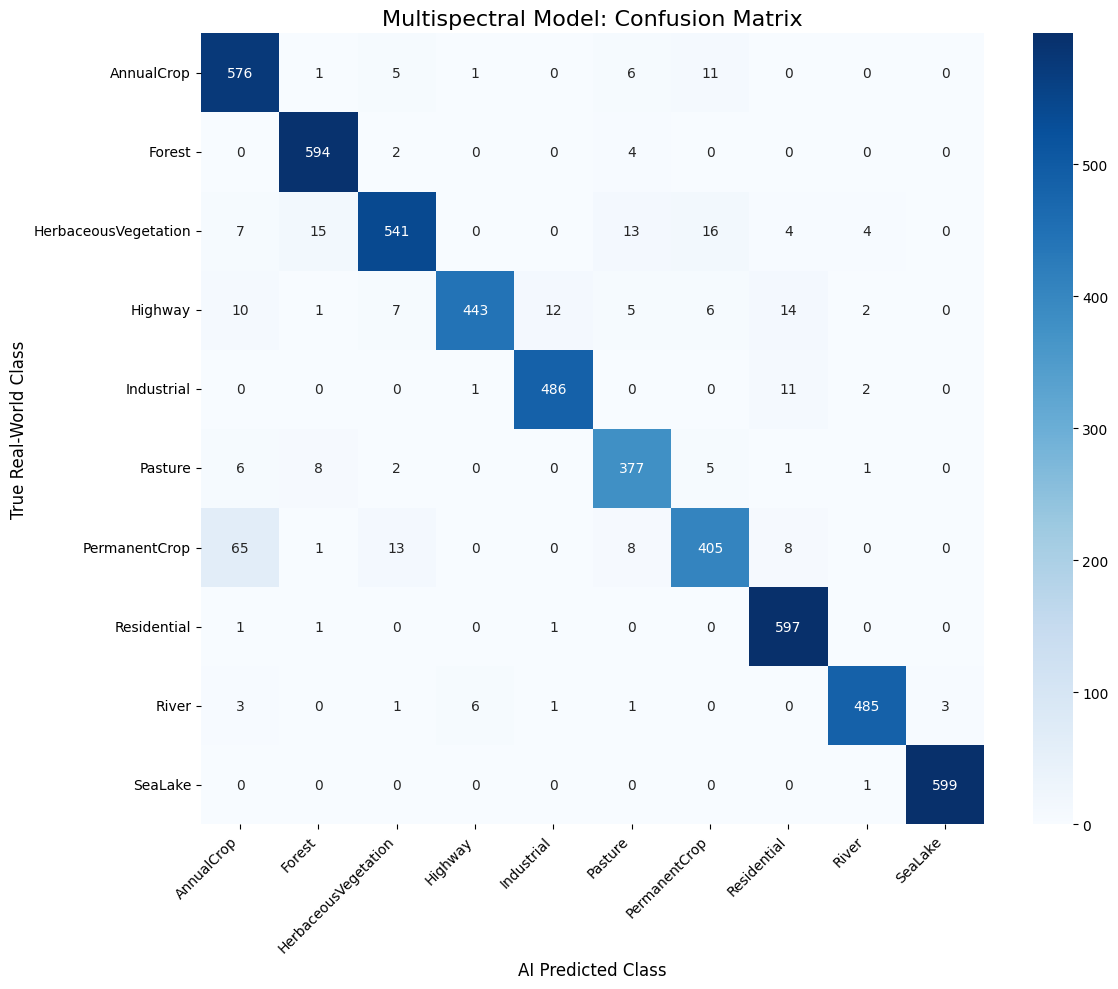

In [ ]:
import numpy as np
import rasterio
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

saved_model_path = '/content/drive/MyDrive/LULC_Thesis_Models/multispectral_model_best.keras'

print("Loading the model from Drive...")
best_model = load_model(saved_model_path)
print("Model loaded successfully")

y_true = y_val
y_pred_probs = []

print("Running predictions on validation data.")

BATCH_SIZE = 32
for i in range(0, len(X_val_paths), BATCH_SIZE):
    batch_paths = X_val_paths[i:i+BATCH_SIZE]
    X_batch = np.empty((len(batch_paths), IMG_SIZE, IMG_SIZE, CHANNELS), dtype=np.float32)

    for j, path in enumerate(batch_paths):
        with rasterio.open(path) as src:
            img = src.read()
            img = np.moveaxis(img, 0, -1)
            img = np.clip(img, 0, MAX_PIXEL_VALUE) / MAX_PIXEL_VALUE
            X_batch[j] = img

    # Predict the probabilities for this batch
    preds = best_model.predict(X_batch, verbose=0)
    y_pred_probs.extend(preds)

# Convert probabilities into final class choices
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("\n=======================================================")
print("      MULTISPECTRAL CLASS REPORT")
print("=======================================================")
print(classification_report(y_true, y_pred_classes, target_names=classes))

# Confusion matrix
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Multispectral Model: Confusion Matrix', fontsize=16)
plt.ylabel('True Real-World Class', fontsize=12)
plt.xlabel('AI Predicted Class', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()